In [1]:
import os
import pandas as pd
from cubes.construct.buildingconfig import load_building_config
from cubes.construct.building import Building
from cubes.package.envconfig import EnvConfig
from cubes.package.simple_simulation import prepare_simulation
#from cubes.package.utilities import get_rdd_file
#from cubes.package import weather
#from cubes.construct.core import materials_evaluator, windows_evaluator
#from geomeppy import IDF
#import pathlib as Path


files_dir = "/workspaces/CUBES/exp/jack/paper/input/"
bc_file_path = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/input/case0/case_0_minimal.json"
#bc_file_path = files_dir + "/building_config.json"
#bc_file_path = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/input/case10/case_10.json"
#bc_file_path = "input_c.json"
#bc_file_path = "/workspaces/CUBES/exp/hannes/Leiden-study/01_evaluate_input/evaluation_deterministic_occupancy/case_0/year_2022/rep_0/input_c.json"

materials = pd.read_pickle("/workspaces/CUBES/cubes/materials.pickle")
windows = pd.read_pickle("/workspaces/CUBES/cubes/windows.pickle")

BC = load_building_config(bc_file_path, files_dir=files_dir)
EC = EnvConfig(files_dir=files_dir)
building=Building(BC,materials,windows)
#building=Building(BC,materials_evaluator(),windows_evaluator())
building.build()
idf = building.get_idf()


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


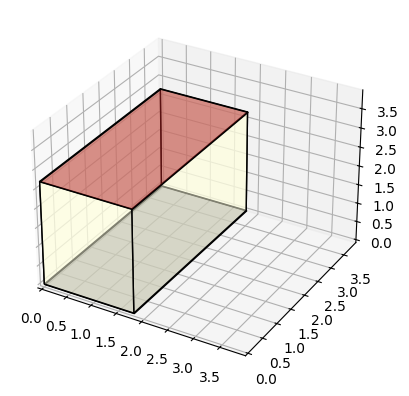

In [6]:
idf.view_model()

In [7]:
#string_test = BC.occupant_schedule_living
#new_list = string_test.split(",")
#changed_list = []
#for entry in new_list:
#
#    if entry[:-1] != "\n":
#        changed_entry = entry[:-4] + "0.25"
#    #else:
#    #    changed_entry = entry
#
#    changed_list.append(changed_entry)
#
#new_sch = ",".join(changed_list)

#sch = pd.read_csv("input/H28_1_schedule.csv", index_col=0)
#sch_2014 = sch.loc["2013-01-01 00:00:00": "2013-12-31 23:50:00"].iloc[:, :4]
#sch_2014.to_csv("input/leedr_schedule_config.sch")

In [8]:
EC = EnvConfig(files_dir=files_dir)
idf = prepare_simulation(idf, BC, EC)

idf.run(output_directory= "/workspaces/CUBES/exp/jack/paper/output",
        expandobjects=True,
        readvars=True,
        weather="/workspaces/CUBES/cubes/data/weather/Cambridgeshire_CC_2022.epw",
        verbose="q",
    )
